In [11]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
ref = np.load("results/ref.npy")
pred = np.load("results/pred.npy")

In [13]:
ref.shape, pred.shape

((7, 100, 3, 256, 256), (7, 100, 3, 256, 256))

In [14]:
def plot_m_means(m_avg, m_avg_pred, save_path):
    fig, axs = plt.subplots(nrows=1, ncols=3, sharey=True, figsize=(12, 4))
    tt = np.arange(1e-11, 1e-9, 1e-11)

    labels = ["$<m_x>$", "$<m_y>$", "$<m_z>$"]
    for i in range(3):
        axs[i].plot(tt, m_avg[:, i], label="true")
        axs[i].plot(tt, m_avg_pred[:, i], label="pred")
        axs[i].set_ylim(-1, 1)
        axs[i].set_xlim(0, 1e-9)
        axs[i].set_title(labels[i])

    plt.show()

In [15]:
m_avg, m_avg_pred = np.mean(ref, axis=(-2, -1)), np.mean(pred, axis=(-2, -1))

In [16]:
m_avg.shape, m_avg_pred.shape

((7, 100, 3), (7, 100, 3))

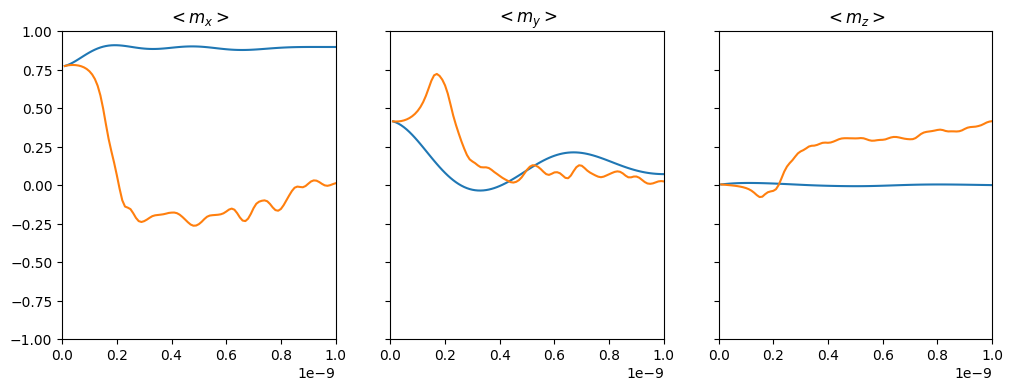

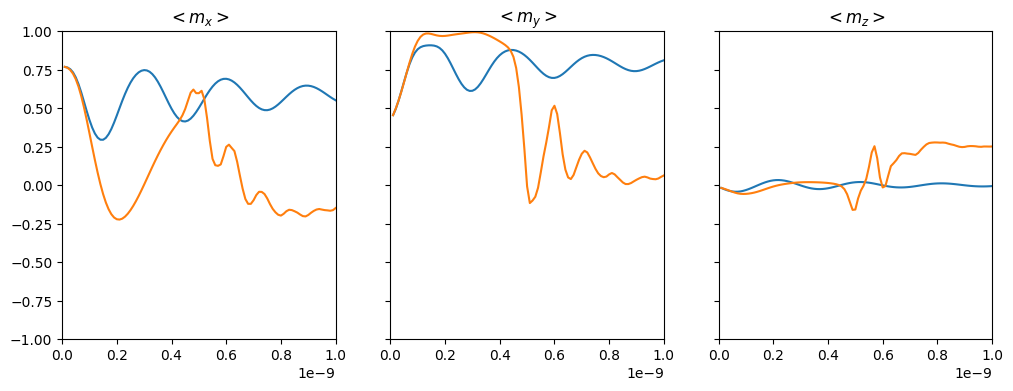

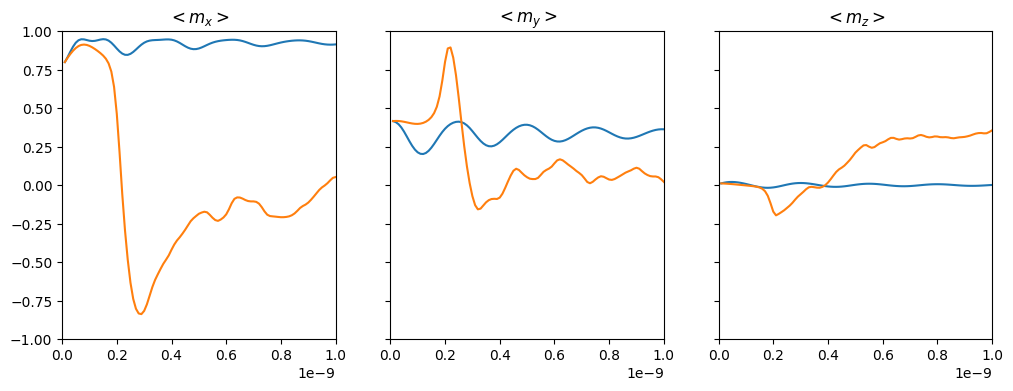

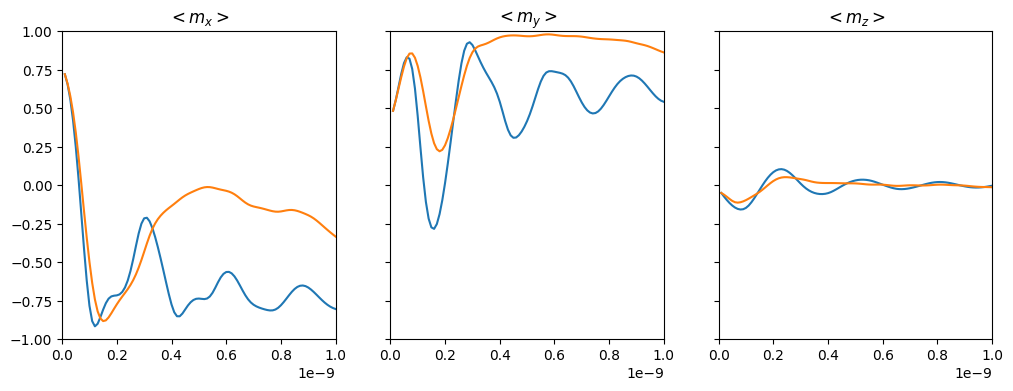

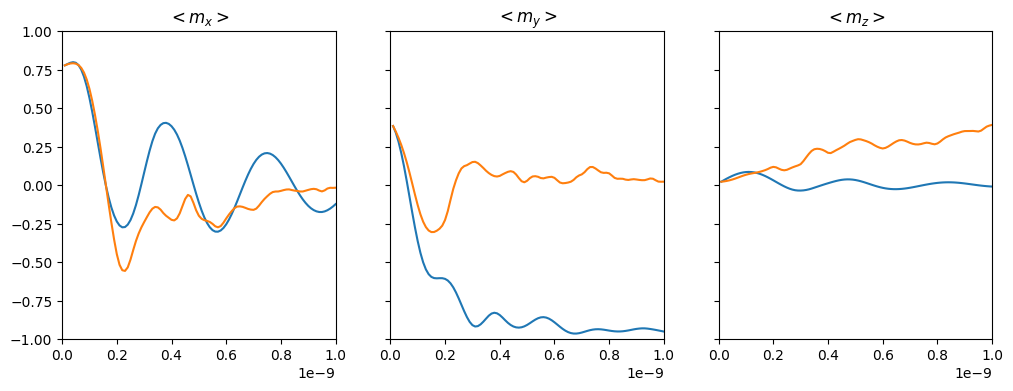

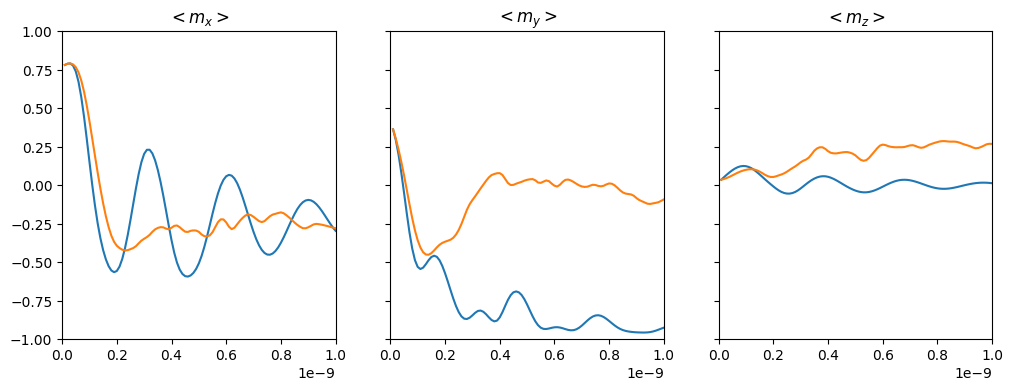

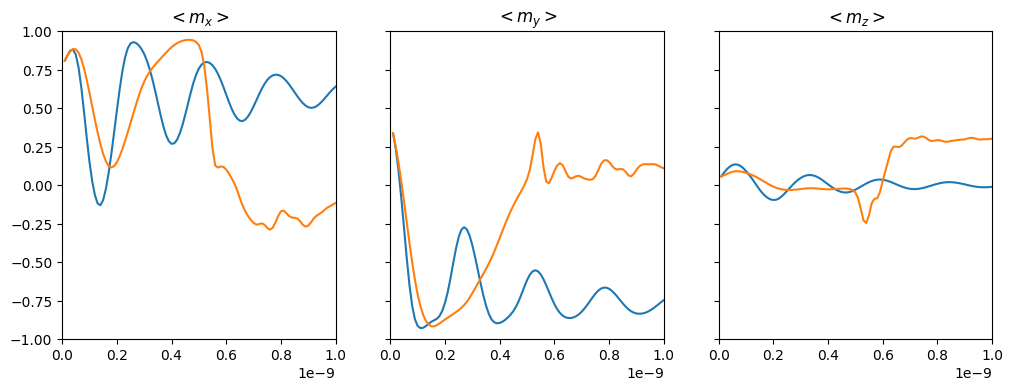

In [17]:
for r, p in zip(m_avg, m_avg_pred):
    plot_m_means(r, p, None)

In [ ]:
for r, p in zip(m_avg, m_avg_pred):
    diff = np.mean(np.square(r, p), axis=(-3, -2, -1))
    norm = np.mean(r, axis=(-3, -2, -1))